In [22]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold
import os
import joblib
import matplotlib.pyplot as plt
import geopandas as gpd
import pgeocode


In [3]:
df_energy = pd.read_parquet('sense_acute_climate.parquet')
rcp26 = pd.read_parquet('../data + code/climate_data/climate_rcp26_sitelevel.parquet')
rcp45 = pd.read_parquet('../data + code/climate_data/climate_rcp45_sitelevel.parquet')
rcp85 = pd.read_parquet('../data + code/climate_data/climate_rcp85_sitelevel.parquet')

Now we have imported our future climate datasets, we can now engineer the future energy usage features for each site using our trained random forests.

In [4]:
# first, need to derive calculated features which we created for the past climate data, as they are fed into the model for future projections.

def engineer_features(df):
    df = df.sort_values(['site_code', 'year', 'month', 'day']).reset_index(drop=True)
    df['HDD'] = (15.5 - df['tas']).clip(lower=0)
    df['CDD'] = (df['tas'] - 22).clip(lower=0)
    df['tas_7day_mean'] = df.groupby('site_code')['tas'].transform(
        lambda x: x.rolling(7, min_periods=1).mean())
    df['tas_lag1'] = df.groupby('site_code')['tas'].shift(1)
    df['tas_lag3'] = df.groupby('site_code')['tas'].shift(3)
    df['heatwave'] = (df.groupby('site_code')['tasmax']
                  .transform(lambda x: (x >= 26).rolling(3, min_periods=3).sum() >= 3)
                  ).astype(int)
    df['extreme_cold'] = (df['tasmin'] < 0).astype(int)

# Invalid dates are defaulted to Wed (2)

    def safe_dayofweek(year, month, day):
        try:
            return pd.Timestamp(year=year, month=month, day=day).dayofweek
        except:
            return 2

    df['day_of_week'] = df.apply(lambda r: safe_dayofweek(r['year'], r['month'], r['day']), axis=1)
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

    return df

rcp26 = engineer_features(rcp26)
rcp45 = engineer_features(rcp45)
rcp85 = engineer_features(rcp85)

In [5]:
### GENERATE PROJECTIONS:


site_features = [
    'tasmax', 'tasmin', 'tas',
    'HDD', 'CDD', 'tas_lag1', 'tas_lag3', 'tas_7day_mean',
    'extreme_cold', 'heatwave', 'hurs', 'sfcWind', 'rsds',
    'month', 'day_of_week', 'is_weekend'
]

all_predictions = []

for energy in ['elec', 'gas']:
    for site in df_energy['site_code'].unique():
        
        model_path = f'trained_models/{site}_{energy}_xgb.pkl'
        if not os.path.exists(model_path):
            continue # not every site has both
        
        model = joblib.load(model_path)
        
        for scenario, df_future in [('rcp26', rcp26), ('rcp45', rcp45), ('rcp85', rcp85)]:
            site_future = df_future[df_future['site_code'] == site].dropna(subset=site_features)  
            site_future = site_future.copy()
            site_future['predicted_kwh'] = model.predict(site_future[site_features])
            site_future['energy_type'] = energy
            site_future['scenario'] = scenario
            
            all_predictions.append(site_future[['site_code', 'year', 'month', 'day',
                                                  'energy_type', 'scenario', 'predicted_kwh']])
        
        print(f"Done: {site} {energy}")

df_predictions = pd.concat(all_predictions, ignore_index=True)
df_predictions.to_parquet('future_predictions.parquet', index=False)
print(f"Saved: {df_predictions.shape}")

Done: R0A06 elec
Done: R0A07 elec
Done: R0A09 elec
Done: R0A66 elec
Done: RCB05 elec
Done: RCB07 elec
Done: RCB55 elec
Done: RCBCA elec
Done: RCBL8 elec
Done: RCBNH elec
Done: RCBP9 elec
Done: RD130 elec
Done: RFSDA elec
Done: RH801 elec
Done: RH802 elec
Done: RH868 elec
Done: RH880 elec
Done: RH8K6 elec
Done: RJC02 elec
Done: RJC46 elec
Done: RJN63 elec
Done: RJN71 elec
Done: RKB01 elec
Done: RKB03 elec
Done: RL131 elec
Done: RLT01 elec
Done: RM102 elec
Done: RM131 elec
Done: RN325 elec
Done: RN3G2 elec
Done: RQ301 elec
Done: RQXM1 elec
Done: RXN01 elec
Done: RXN02 elec
Done: R0A01 gas
Done: R0A06 gas
Done: RD130 gas
Done: RH801 gas
Done: RH868 gas
Done: RH8K6 gas
Done: RL131 gas
Done: RQXM1 gas
Done: RXN02 gas
Saved: (2503503, 7)


In [6]:
df_predictions = pd.read_parquet('future_predictions.parquet')
print(df_predictions.shape)
print(df_predictions.head())
print(df_predictions['scenario'].value_counts())
print(df_predictions['energy_type'].value_counts())
print(df_predictions['predicted_kwh'].describe())

(2503503, 7)
  site_code  year  month  day energy_type scenario  predicted_kwh
0     R0A06  2027      1    4        elec    rcp26    3354.341553
1     R0A06  2027      1    5        elec    rcp26    3492.177979
2     R0A06  2027      1    6        elec    rcp26    3376.853271
3     R0A06  2027      1    7        elec    rcp26    3634.261963
4     R0A06  2027      1    8        elec    rcp26    3541.845459
scenario
rcp26    834501
rcp45    834501
rcp85    834501
Name: count, dtype: int64
energy_type
elec    1979514
gas      523989
Name: count, dtype: int64
count    2.503503e+06
mean     1.673468e+04
std      3.170643e+04
min     -3.442570e+03
25%      1.891290e+03
50%      6.115612e+03
75%      1.561944e+04
max      3.389878e+05
Name: predicted_kwh, dtype: float64


---
Projections have run. Now for visualisation:
 plot to see what future trends are looking like

Historical electricity daily mean (mean across sites): 9846.3 kWh
Historical gas daily mean (mean across sites): 43141.9 kWh


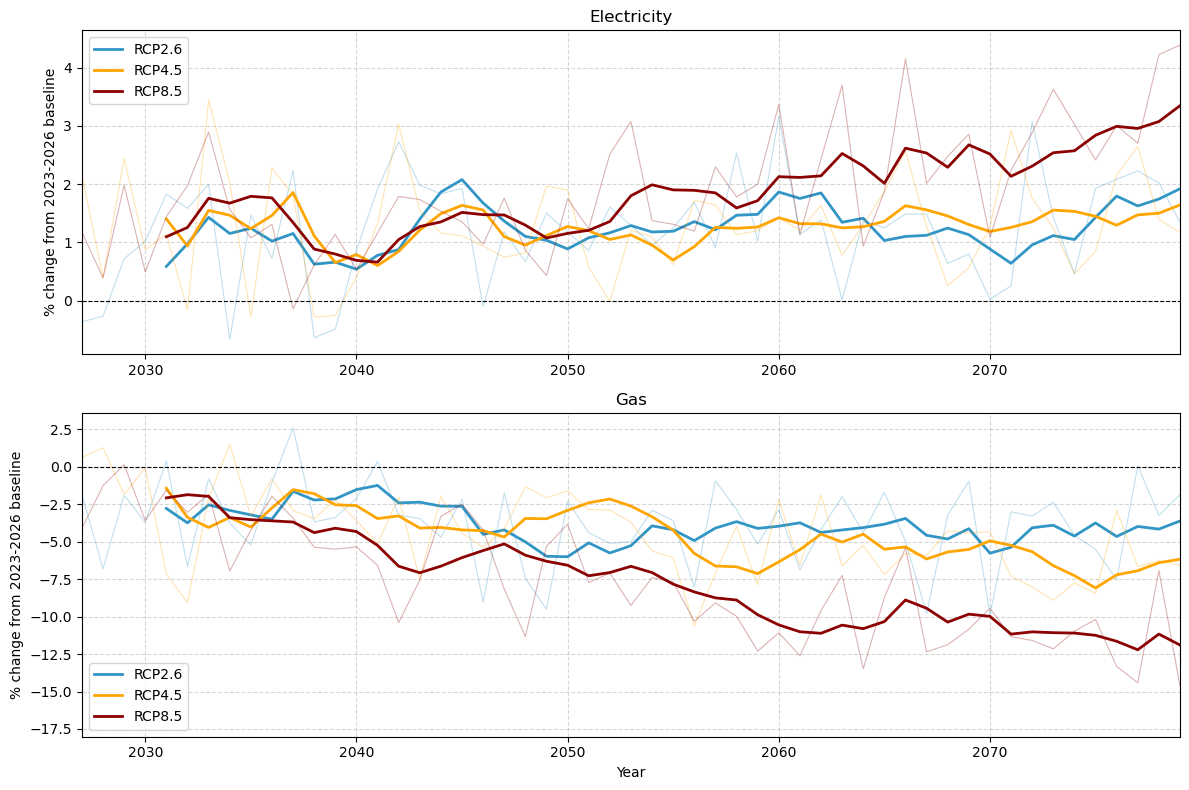

In [15]:
# predictions:

# Title: Projected energy consumption (% change from 2023-2026 daily mean)


# historical baseline as daily mean per site
hist_elec_baseline_per_site = df_energy[(df_energy['energy_type'] == 'elec') &
                                         (df_energy['consumption'] > 0) &
                                         (df_energy['datetime'].dt.year.between(2023, 2026))].groupby(
    'site_code')['consumption'].mean()

hist_gas_baseline_per_site = df_energy[(df_energy['energy_type'] == 'gas') &
                                        (df_energy['consumption'] > 0) &
                                        (df_energy['datetime'].dt.year.between(2023, 2026))].groupby(
    'site_code')['consumption'].mean()

print(f"Historical electricity daily mean (mean across sites): {hist_elec_baseline_per_site.mean():.1f} kWh")
print(f"Historical gas daily mean (mean across sites): {hist_gas_baseline_per_site.mean():.1f} kWh")

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

colors = {'rcp26': '#3195C5', 'rcp45': 'orange', 'rcp85': 'darkred'}
labels = {'rcp26': 'RCP2.6', 'rcp45': 'RCP4.5', 'rcp85': 'RCP8.5'}

for scenario in ['rcp26', 'rcp45', 'rcp85']:
    for ax, energy, hist_baseline_per_site in zip(
        axes,
        ['elec', 'gas'],
        [hist_elec_baseline_per_site, hist_gas_baseline_per_site]
    ):
        # per-site daily mean from predictions per year
        site_annual = df_predictions[(df_predictions['energy_type'] == energy) &
                                      (df_predictions['scenario'] == scenario)].groupby(
            ['site_code', 'year'])['predicted_kwh'].mean().reset_index()
        
        # merge historical baseline per site
        site_annual = site_annual.merge(
            hist_baseline_per_site.reset_index().rename(
                columns={'consumption': 'hist_baseline'}),
            on='site_code', how='left'
        )
        
        # percentage change per site per year
        site_annual['pct_change'] = (site_annual['predicted_kwh'] - 
                                      site_annual['hist_baseline']) / site_annual['hist_baseline'] * 100
        
        # mean across sites per year
        annual_mean = site_annual.groupby('year')['pct_change'].mean().reset_index().sort_values('year')
        
        smoothed = annual_mean['pct_change'].rolling(5).mean()
        ax.plot(annual_mean['year'], annual_mean['pct_change'],
                color=colors[scenario], alpha=0.3, linewidth=0.8)
        ax.plot(annual_mean['year'], smoothed,
                color=colors[scenario], linewidth=2, label=labels[scenario])

axes[0].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axes[0].set_ylabel('% change from 2023-2026 baseline')
axes[0].set_title('Electricity')
axes[0].legend()

axes[1].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_ylabel('% change from 2023-2026 baseline')
axes[1].set_title('Gas')
axes[1].set_xlabel('Year')
axes[1].legend()

axes[0].set_xlim(2027, 2079)
axes[1].set_xlim(2027, 2079)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

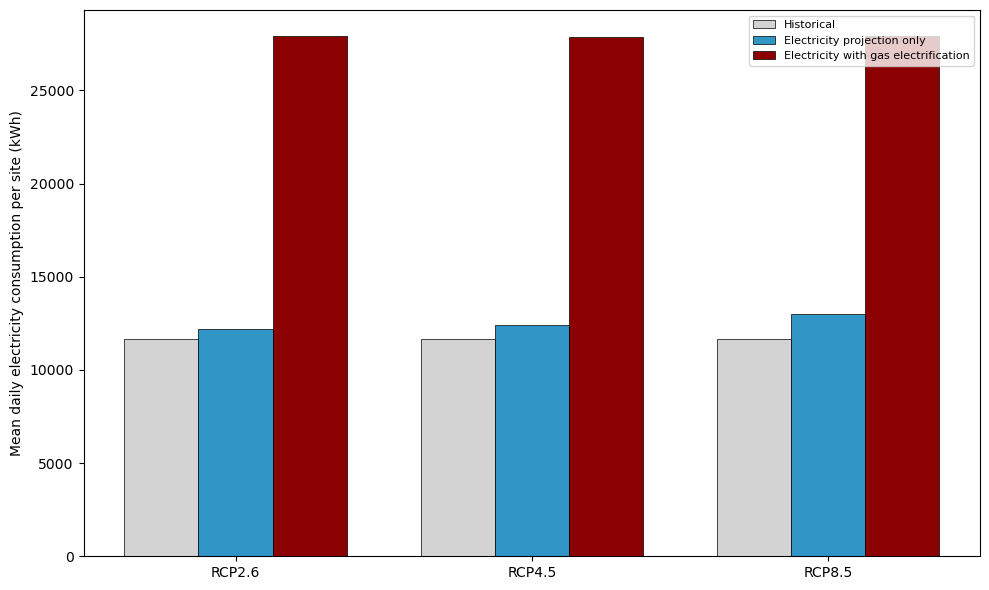

In [26]:
# electrification:
#Title: Projected electricity demand under electrification - 8 sites (2070-2080)

eff_coef = 3.0

# 8 sites with both gas and electricity
gas_sites = set(df_predictions[df_predictions['energy_type'] == 'gas']['site_code'].unique())
elec_sites = set(df_predictions[df_predictions['energy_type'] == 'elec']['site_code'].unique())
both_site_codes = list(gas_sites & elec_sites)

# historical electricity baseline for 8 sites
hist_elec_8 = df_energy[(df_energy['energy_type'] == 'elec') &
                          (df_energy['site_code'].isin(both_site_codes)) &
                          (df_energy['consumption'] > 0) &
                          (df_energy['datetime'].dt.year.between(2023, 2026))].groupby(
    'site_code')['consumption'].mean().reset_index()
hist_elec_8.columns = ['site_code', 'hist_elec']

fig, ax = plt.subplots(figsize=(10, 6))

scenarios = ['rcp26', 'rcp45', 'rcp85']
x = np.arange(len(scenarios))
width = 0.25

current_vals = hist_elec_8['hist_elec'].mean()

future_elec_vals = []
future_total_vals = []

for scenario in scenarios:
    elec_site = df_predictions[(df_predictions['energy_type'] == 'elec') &
                                (df_predictions['scenario'] == scenario) &
                                (df_predictions['site_code'].isin(both_site_codes)) &
                                (df_predictions['year'].between(2070, 2080))].groupby(
        'site_code')['predicted_kwh'].mean().reset_index()

    gas_site = df_predictions[(df_predictions['energy_type'] == 'gas') &
                               (df_predictions['scenario'] == scenario) &
                               (df_predictions['site_code'].isin(both_site_codes)) &
                               (df_predictions['year'].between(2070, 2080))].groupby(
        'site_code')['predicted_kwh'].mean().reset_index()
    gas_site.columns = ['site_code', 'gas_kwh']

    combined = elec_site.merge(gas_site, on='site_code', how='left')
    combined['total'] = combined['predicted_kwh'] + combined['gas_kwh'] / eff_coef

    future_elec_vals.append(combined['predicted_kwh'].mean())
    future_total_vals.append(combined['total'].mean())

ax.bar(x - width, [current_vals]*3, width, label='Historical',
       color='lightgrey', edgecolor='black', linewidth=0.5)
ax.bar(x, future_elec_vals, width, label='Electricity projection only',
       color='#3195C5', edgecolor='black', linewidth=0.5)
ax.bar(x + width, future_total_vals, width, label=f'Electricity with gas electrification',
       color='darkred', edgecolor='black', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(['RCP2.6', 'RCP4.5', 'RCP8.5'])
ax.set_ylabel('Mean daily electricity consumption per site (kWh)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

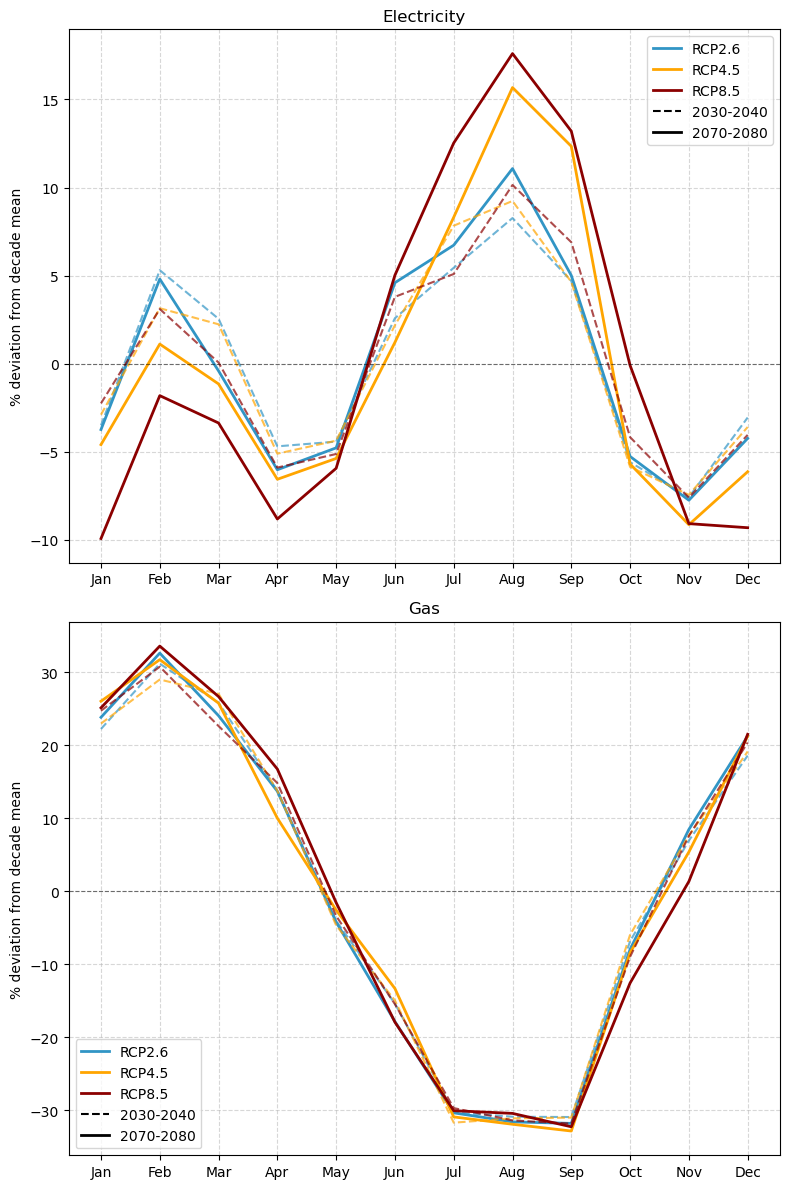

In [30]:
### plot seasonal profile as % deviation from decade mean

fig, axes = plt.subplots(2, 1, figsize=(8, 12))

colors = {'rcp26': '#3195C5', 'rcp45': 'orange', 'rcp85': 'darkred'}
labels = {'rcp26': 'RCP2.6', 'rcp45': 'RCP4.5', 'rcp85': 'RCP8.5'}
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_idx = range(1, 13)

for scenario in ['rcp26', 'rcp45', 'rcp85']:

    early = df_predictions[
        (df_predictions['scenario'] == scenario) &
        (df_predictions['year'] >= 2030) &
        (df_predictions['year'] <= 2040)
    ]

    late = df_predictions[
        (df_predictions['scenario'] == scenario) &
        (df_predictions['year'] >= 2070) &
        (df_predictions['year'] <= 2080)
    ]

    # electricity 
    early_elec = early[early['energy_type'] == 'elec'].groupby('month')['predicted_kwh'].mean().reindex(month_idx)
    late_elec = late[late['energy_type'] == 'elec'].groupby('month')['predicted_kwh'].mean().reindex(month_idx)

    early_elec_norm = (early_elec - early_elec.mean()) / early_elec.mean() * 100
    late_elec_norm = (late_elec - late_elec.mean()) / late_elec.mean() * 100

    axes[0].plot(month_idx, early_elec_norm, color=colors[scenario], linewidth=1.5, linestyle='--', alpha=0.7)
    axes[0].plot(month_idx, late_elec_norm, color=colors[scenario], linewidth=2, label=labels[scenario])

    # gas 
    early_gas = early[early['energy_type'] == 'gas'].groupby('month')['predicted_kwh'].mean().reindex(month_idx)
    late_gas = late[late['energy_type'] == 'gas'].groupby('month')['predicted_kwh'].mean().reindex(month_idx)

    early_gas_norm = (early_gas - early_gas.mean()) / early_gas.mean() * 100
    late_gas_norm = (late_gas - late_gas.mean()) / late_gas.mean() * 100

    axes[1].plot(month_idx, early_gas_norm, color=colors[scenario], linewidth=1.5, linestyle='--', alpha=0.7)
    axes[1].plot(month_idx, late_gas_norm, color=colors[scenario], linewidth=2, label=labels[scenario])

for ax, title in zip(axes, ['Electricity', 'Gas']):
    ax.plot([], [], color='black', lw=1.5, linestyle='--', label='2030-2040')  # legend-only entry
    ax.plot([], [], color='black', lw=2, linestyle='-', label='2070-2080')     # legend-only entry
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_xticks(month_idx)
    ax.set_xticklabels(months)
    ax.set_ylabel('% deviation from decade mean')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

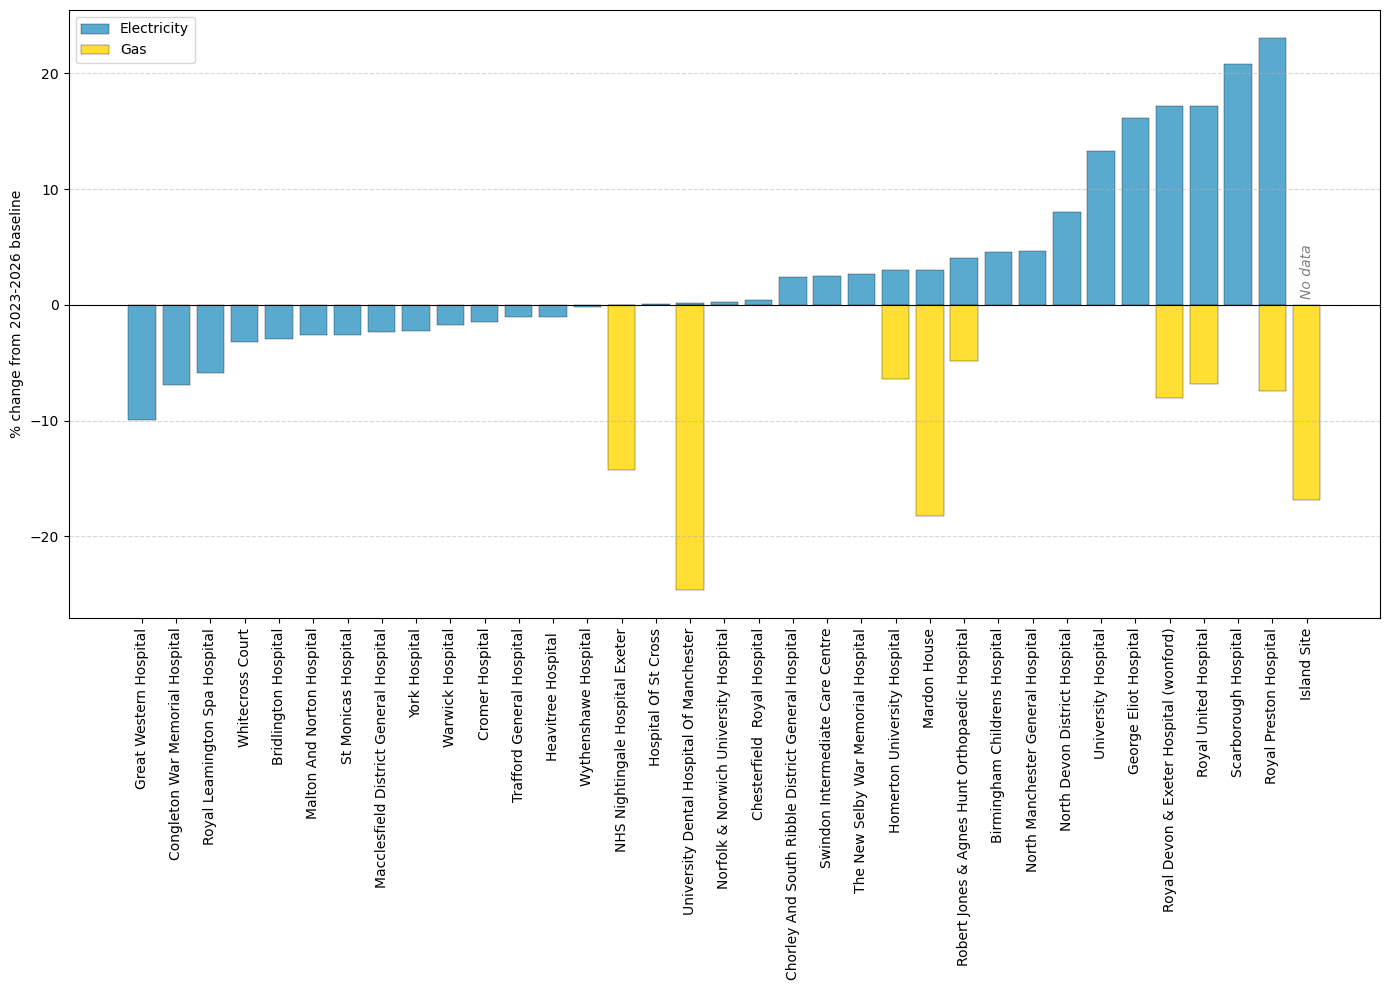

In [19]:
# Title: Projected % change in daily mean consumption by site (RCP8.5, 2070-2080)

# historical daily mean per site
hist_elec_per_site = df_energy[(df_energy['energy_type'] == 'elec') &
                                (df_energy['consumption'] > 0) &
                                (df_energy['datetime'].dt.year.between(2023, 2026))].groupby(
    'site_code')['consumption'].mean()

hist_gas_per_site = df_energy[(df_energy['energy_type'] == 'gas') &
                               (df_energy['consumption'] > 0) &
                               (df_energy['datetime'].dt.year.between(2023, 2026))].groupby(
    'site_code')['consumption'].mean()

# 2070-2080 daily mean per site
future = df_predictions[(df_predictions['year'] >= 2070) &
                         (df_predictions['year'] <= 2080)]

future_mean = future.groupby(['site_code', 'energy_type', 'scenario'])['predicted_kwh'].mean().reset_index()
future_mean.columns = ['site_code', 'energy_type', 'scenario', 'future_mean']

future_mean = future_mean.merge(hist_elec_per_site.rename('hist_elec'), on='site_code', how='left')
future_mean = future_mean.merge(hist_gas_per_site.rename('hist_gas'), on='site_code', how='left')

def calc_pct(row):
    if row['energy_type'] == 'elec':
        return (row['future_mean'] - row['hist_elec']) / row['hist_elec'] * 100
    else:
        return (row['future_mean'] - row['hist_gas']) / row['hist_gas'] * 100

future_mean['pct_change'] = future_mean.apply(calc_pct, axis=1)

site_info = df_energy.drop_duplicates('site_code')[['site_code', 'site_name']]
pct_change_hist = future_mean.merge(site_info, on='site_code', how='left')

rcp85 = pct_change_hist[pct_change_hist['scenario'] == 'rcp85']
elec_data = rcp85[rcp85['energy_type'] == 'elec'].set_index('site_name')['pct_change']
gas_data = rcp85[rcp85['energy_type'] == 'gas'].set_index('site_name')['pct_change']

# bar chart
fig, ax = plt.subplots(figsize=(14, 10))

non_island = sorted([s for s in set(elec_data.index.tolist() + gas_data.index.tolist())
                     if 'Island' not in s],
                    key=lambda s: elec_data.get(s, 0))
island_sites = [s for s in gas_data.index if 'Island' in s]
all_sites = non_island + island_sites

x_pos = range(len(all_sites))

elec_plotted = False
gas_plotted = False

for i, site in enumerate(all_sites):
    if site in elec_data.index:
        ax.bar(i, elec_data[site], color='#3195C5', alpha=0.8,
               edgecolor='black', linewidth=0.3,
               label='Electricity' if not elec_plotted else '')
        elec_plotted = True
    else:
        ax.text(i, 0.5, 'No data', rotation=90, fontsize=10,
                ha='center', va='bottom', color='grey', style='italic')

    if site in gas_data.index:
        ax.bar(i, gas_data[site], color='gold', alpha=0.8,
               edgecolor='black', linewidth=0.3,
               label='Gas' if not gas_plotted else '')
        gas_plotted = True

ax.set_xticks(list(x_pos))
ax.set_xticklabels(all_sites, rotation=90, fontsize=10)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_ylabel('% change from 2023-2026 baseline')
ax.legend()
ax.yaxis.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

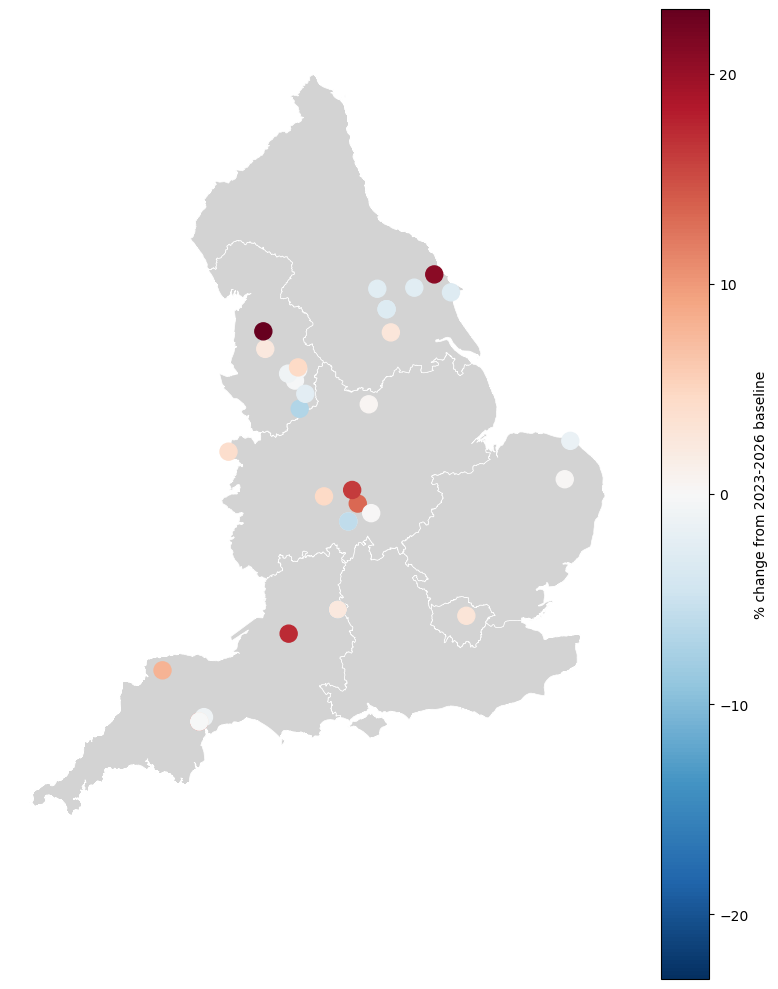

In [ ]:
# Title: Projected electricity % change by location (RCP8.5, 2070-2080)

sites_geo = df_energy.drop_duplicates('site_code')[['site_code', 'postcode']].copy()
sites_geo['postcode'] = sites_geo['postcode'].str.strip()

nomi = pgeocode.Nominatim('gb')
geo = nomi.query_postal_code(sites_geo['postcode'].tolist())
sites_geo['latitude'] = geo['latitude'].values
sites_geo['longitude'] = geo['longitude'].values

uk = gpd.read_file('NHS_England_Regions_January_2024_EN_BFE_-6109213648786504635.geojson') 
uk = uk.to_crs(epsg=4326)

elec_pct = pct_change_hist[(pct_change_hist['scenario'] == 'rcp85') &
                            (pct_change_hist['energy_type'] == 'elec')][['site_code', 'pct_change']]

plot_data = sites_geo.merge(elec_pct, on='site_code', how='left')

fig, ax = plt.subplots(figsize=(8, 10))

uk.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.5)

scatter = ax.scatter(plot_data['longitude'], plot_data['latitude'],
                     c=plot_data['pct_change'], cmap='RdBu_r',
                     s=150, zorder=5, 
                     vmin=-plot_data['pct_change'].abs().max(),
                     vmax=plot_data['pct_change'].abs().max())

plt.colorbar(scatter, ax=ax, label='% change from 2023-2026 baseline')
ax.set_xlim(-6, 2)
ax.set_ylim(49, 56)
ax.set_axis_off()

plt.tight_layout()
plt.show()